In [2]:
!pip install anndata==0.8.0

In [1]:
import pandas as pd

In [1]:
from samalg import SAM
import scanpy as sc
import statistics
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pandas as pd
import matplotlib.colors
import scipy
import numpy as np
import sklearn.metrics as metrics
from scipy import sparse
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import pickle
from samap.utils import (save_samap, load_samap)
import anndata as ad

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [88]:
sam = SAM()
sam.load_data('Active_SAM_joined/SAM_CJ_non')
gene_dict = {}
for i in range(len(sam.adata.var_names)):
    gene_dict[sam.adata.var_names[i]] = i

In [21]:
sam.adata.obs

,n_counts,n_genes,key,subclass_lc,ss_subclass,leiden_clusters,ss_subclass_nounlabeled,ss_subclass_nounlabeled_nn,ss_subclass_crossed_nn
AAACCCAAGACATAAC,14080.0,3690,Run14_sample2,221,129 VMH Nr5a1 Glut,107,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut
AAACCCAAGGCATGCA,12556.0,3373,Run14_sample2,76,126 ARH-PVp Tbx3 Glut,95,126 ARH-PVp Tbx3 Glut,126 ARH-PVp Tbx3 Glut,126 ARH-PVp Tbx3 Glut
AAACCCAAGGCTCACC,16252.0,3598,Run14_sample2,23,cc_m061_m062,80,cc_m061_m062,cc_m061_m062,cc_m061_m062
AAACCCAAGGTGATCG,18742.0,4140,Run14_sample2,123,cc_m136_m138,40,cc_m136_m138,cc_m136_m138,138 PH Pitx2 Glut
AAACCCACAACACACT,19802.0,4519,Run14_sample2,293,136 PMv-TMv Pitx2 Glut,76,136 PMv-TMv Pitx2 Glut,136 PMv-TMv Pitx2 Glut,136 PMv-TMv Pitx2 Glut
...,...,...,...,...,...,...,...,...,...
TTTGTTGGTGGTACAG,5410.0,2053,Run08_sample2,377,119 SI-MA-LPO-LHA Skor1 Glut,57,119 SI-MA-LPO-LHA Skor1 Glut,119 SI-MA-LPO-LHA Skor1 Glut,119 SI-MA-LPO-LHA Skor1 Glut
TTTGTTGGTGTAAATG,2837.0,1589,Run08_sample2,66,323 Ependymal NN,29,323 Ependymal NN,323 Ependymal NN,323 Ependymal NN
TTTGTTGTCCAGTGTA,15224.0,3699,Run08_sample2,70,Unlabeled,94,cc_20,cc_20,cc_cj_6
TTTGTTGTCGCCAGAC,5942.0,2292,Run08_sample2,256,210 PRT Mecom Gaba,6,210 PRT Mecom Gaba,210 PRT Mecom Gaba,210 PRT Mecom Gaba


In [12]:
NN_label = []
level = 'ss_subclass_crossed_nn'
for item in sam.adata.obs[level]:
    if item[-2:] == 'NN':
        NN_label.append('Non neuron')
    else:
        NN_label.append('Neuron')

In [13]:
sam.adata.obs['Neuron'] = NN_label

In [14]:
ordered_genes = sam.identify_marker_genes_ratio('Neuron')

In [15]:
ordered_genes

{'Neuron': array(['CELF4', 'LINGO2', 'PCDH7', ..., 'LOC138647122', 'LOC138646104',
        'LOC138671721'], dtype='<U13'),
 'Non neuron': array(['EGF', 'CARNS1', 'SLC1A3', ..., 'LOC138657909', 'HIPK4', 'POU4F2'],
       dtype='<U13')}

In [12]:
orthogroups = pd.read_csv('Vert_emapper_allorgs_03272025.csv', index_col = 'Unnamed: 0')
print(orthogroups.loc[orthogroups.index[np.where(orthogroups['MM'] == 'Syt1')],'DR'])
print(orthogroups.loc[orthogroups.index[np.where(orthogroups['MM'] == 'Rbfox3')],'DR'])

494XY@7742    syt1a,syt1b,LOC103909492,syt5b,syt1b_1
Name: DR, dtype: object
Series([], Name: DR, dtype: object)


In [15]:
test_genes = list(ordered_genes['Non neuron'][:5]) + ['Syt1', 'Rbfox2'] + list(ordered_genes['Neuron'][:5])

In [36]:
ordered_genes['Neuron'][:5]

array(['LOC142835222', 'Cntnap2', 'Nrxn3', 'Tenm2', 'Lingo2'],
      dtype='<U14')

In [5]:
sam.clustering(param = 1)

In [22]:
for item in sam.adata.var_names:
    if 'slc32' in item:
        print(item)

In [15]:
'mv_Nrxn3' in sam.NBata.var_names

True

In [24]:
test_genes = ['SYT1','RBFOX2']

In [15]:
test_genes = ['LOC138675902','LINGO2']

In [7]:
test_genes = ['SYT1','LINGO2']

In [22]:
m = pd.read_csv('BLASTMAPPING/maps/active_maps/hypo_proj/drmg/dr_to_mg.txt',delimiter = '\t', header = None)

In [24]:
m[m[0] == 'tmsb2']

,0,1,2,3,4,5,6,7,8,9,10,11


In [44]:
sam.adata.obs.columns

Index(['n_counts', 'n_genes', 'key', 'subclass_lc', 'ss_subclass',
       'leiden_clusters', 'ss_subclass_nounlabeled',
       'ss_subclass_nounlabeled_nn', 'ss_subclass_crossed_nn'],
      dtype='object')

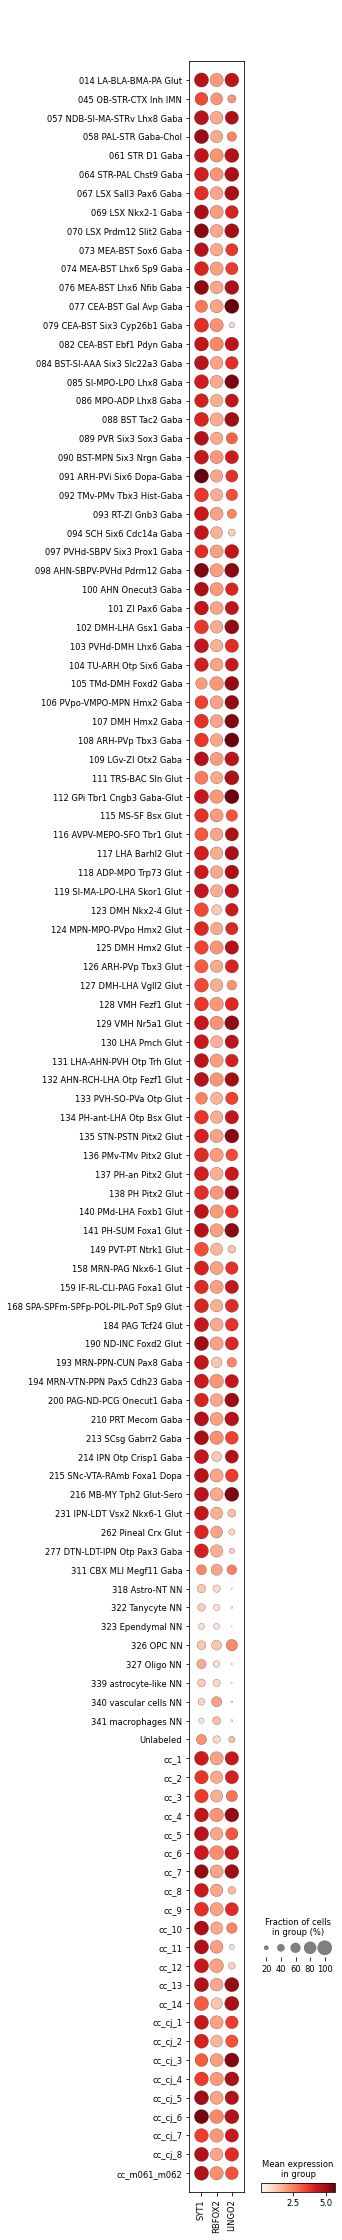

In [46]:
sc.pl.dotplot(sam.adata, var_names = ['SYT1','RBFOX2','LINGO2'], groupby='ss_subclass_crossed_nn')

In [4]:
test_genes = ['qki','dnm3','syt1','lingo2']

In [23]:
'Rbfox2','Syt1','Tenm2'

('Rbfox2', 'Syt1', 'Tenm2')

In [29]:
fin_vals = {}
for item in sam.adata.obs['subclass_id_label_mapping_nounlabeled'].unique():
    exp = np.average(sam.adata[sam.adata.obs['subclass_id_label_mapping_nounlabeled'] == item].X.A[:,gene_dict['SYT1']])
    fin_vals[item] = exp

(array([ 4.,  3.,  3.,  6.,  9., 13., 16., 23., 13.,  9.]),
 array([0.46889332, 0.9199271 , 1.370961  , 1.8219948 , 2.2730286 ,
        2.7240624 , 3.175096  , 3.6261299 , 4.0771637 , 4.528198  ,
        4.9792314 ], dtype=float32),
 <BarContainer object of 10 artists>)

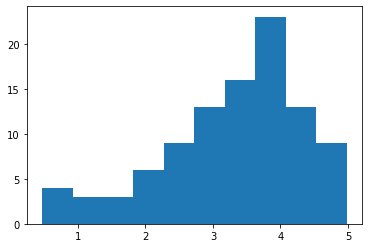

In [30]:
plt.hist(fin_vals.values())

In [182]:
sam.adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_counts', 'n_genes',
       'key', 'subclass_id_label_mapping', 'subclass_id_label_lc',
       'leiden_clusters', 'subclass_id_label_mapping_nounlabeled',
       'neurotransmitter', 'region_label', 'subclass_id_label_reduced_mapping',
       'subclass_id_label_reduced_lc',
       'subclass_id_label_reduced_mapping_nounlabeled',
       'leiden_clusters_formarkers', 'leiden_removal', 'nCount_SCT',
       'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5',
       'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac',
       'eq_subclass_nounlabeled', 'NN', 'ss_subclass',
       'ss_subclass_nounlabeled', 'ss_subclass_nounlabeled_03102026',
       'ss_subclass_nounlabeled_03102026_crossed'],
      dtype='object')

In [189]:
#MO NON NEURON MARKERS
fin_NN = {i:[] for i in sam.adata.obs['ss_subclass_nounlabeled_03102026']}
for item in sam.adata.obs['ss_subclass_nounlabeled_03102026'].unique():
    raw_exp = sam.adata[sam.adata.obs['ss_subclass_nounlabeled_03102026'] == item].X.A
    exp = np.average(raw_exp[:,gene_dict['Syt1']])
    fin_NN[item].append(exp < 1)
    exp = np.average(raw_exp[:,gene_dict['Ptgds']])
    fin_NN[item].append(exp > .25)
    exp = np.average(raw_exp[:,gene_dict['Rbfox2']])
    fin_NN[item].append(exp < 1.25)
    
NN_CT = []
for item in fin_NN:
    if np.sum(fin_NN[item]) > 1:
        print(item)
        NN_CT.append(item)
    elif item[-2:] == 'NN':
        print('Missing ' + item)

327 Oligo NN
322 Tanycyte NN
334 Microglia NN
326 OPC NN


In [58]:
print(fin_NN['mo_46'])

[True, False, False]


In [22]:
sam.adata.obs.columns

Index(['n_counts', 'n_genes', 'key', 'subclass_lc', 'ss_subclass',
       'leiden_clusters', 'ss_subclass_nounlabeled',
       'ss_subclass_nounlabeled_nn', 'ss_subclass_crossed_nn'],
      dtype='object')

In [74]:
#MV NON NEURON MARKERS
fin_NN = {i:[] for i in sam.adata.obs['ss_subclass_crossed_nn']}
A = sam.adata.X.A
for item in sam.adata.obs['ss_subclass_crossed_nn'].unique():
    mask = sam.adata.obs['ss_subclass_crossed_nn'] == item
    raw_exp = A[mask,:]
    exp = np.average(raw_exp[:,gene_dict['Rbfox3']])
    fin_NN[item].append(exp < .5)
    exp = np.average(raw_exp[:,gene_dict['Lingo2']])
    fin_NN[item].append(exp < 1)
    
NN_CT = []
for item in fin_NN:
    if np.sum(fin_NN[item]) > 1:
        print(item)
        NN_CT.append(item)
    elif item[-2:] == 'NN':
        print('Missing ' + item)

318 Astro-NT NN
326 OPC NN
322 Tanycyte NN
327 Oligo NN
333 Endo NN
341 macrophages NN
330 VLMC NN
319 Astro-TE NN
339 astrocyte-like NN
321 Astroependymal NN
323 Ependymal NN
340 vascular cells NN


In [28]:
sam.adata.obs.columns

Index(['n_counts', 'n_genes', 'key', 'subclass_lc', 'ss_subclass',
       'leiden_clusters', 'ss_subclass_nounlabeled',
       'ss_subclass_nounlabeled_nn', 'ss_subclass_crossed_nn'],
      dtype='object')

In [93]:
#CJ NON NEURON MARKERS
fin_NN = {i:[] for i in sam.adata.obs['ss_subclass_crossed_nn']}
for item in sam.adata.obs['ss_subclass_crossed_nn'].unique():
    raw_exp = sam.adata[sam.adata.obs['ss_subclass_crossed_nn'] == item].X.A
    exp = np.average(raw_exp[:,gene_dict['SYT1']])
    fin_NN[item].append(exp < 2)
    exp = np.average(raw_exp[:,gene_dict['RBFOX2']])
    fin_NN[item].append(exp < 1.25)
    exp = np.average(raw_exp[:,gene_dict['PTPRN2']])
    fin_NN[item].append(exp < 2)
    
NN_CT = []
for item in fin_NN:
    if np.sum(fin_NN[item]) > 1:
        print(item)
        NN_CT.append(item)
    elif item[-2:] == 'NN':
        print('Missing ' + item)

327 Oligo NN
326 OPC NN
319 Astro-TE NN
318 Astro-NT NN
339 astrocyte-like NN
341 macrophages NN
Unlabeled
323 Ependymal NN
322 Tanycyte NN
330 VLMC NN
329 ABC NN
325 CHOR NN
340 vascular cells NN
333 Endo NN


In [67]:
#CC NON NEURON MARKERS
fin_NN = {i:[] for i in sam.adata.obs['ss_subclass_crossed_nn']}
for item in sam.adata.obs['ss_subclass_crossed_nn'].unique():
    raw_exp = sam.adata[sam.adata.obs['ss_subclass_crossed_nn'] == item].X.A
    exp = np.average(raw_exp[:,gene_dict['SYT1']])
    fin_NN[item].append(exp < 2)
    exp = np.average(raw_exp[:,gene_dict['RBFOX2']])
    fin_NN[item].append(exp < 1.5)
    exp = np.average(raw_exp[:,gene_dict['LINGO2']])
    fin_NN[item].append(exp < 1.5)
    
NN_CT = []
for item in fin_NN:
    if np.sum(fin_NN[item]) > 1:
        print(item)
        NN_CT.append(item)
    elif item[-2:] == 'NN':
        print('Missing ' + item)

339 astrocyte-like NN
327 Oligo NN
326 OPC NN
318 Astro-NT NN
Unlabeled
322 Tanycyte NN
341 macrophages NN
340 vascular cells NN
323 Ependymal NN


In [219]:
#AC NON NEURON MARKER
fin_NN = {i:[] for i in sam.adata.obs['ss_subclass_v3_nounlabeled']}
for item in sam.adata.obs['ss_subclass_v3_nounlabeled'].unique():
    raw_exp = sam.adata[sam.adata.obs['ss_subclass_v3_nounlabeled'] == item].X.A
    exp = np.average(raw_exp[:,gene_dict['syt1']])
    fin_NN[item].append(exp < 1)
    exp = np.average(raw_exp[:,gene_dict['rbfox2']])
    fin_NN[item].append(exp < .6)
    exp = np.average(raw_exp[:,gene_dict['nrxn1']])
    fin_NN[item].append(exp < 2)
    exp = np.average(raw_exp[:,gene_dict['celf4']])
    fin_NN[item].append(exp < 2)
    
NN_CT = []
for item in fin_NN:
    if np.sum(fin_NN[item]) > 2:
        print(item)
        NN_CT.append(item)
    elif item[-2:] == 'NN':
        print('Missing ' + item)

327 Oligo NN
322 Tanycyte NN
330 VLMC NN
334 Microglia NN
319 Astro-TE NN
329 ABC NN
ac_4
ac_12
338 Lymphoid NN
326 OPC NN
ac_16
333 Endo NN
335 BAM NN
ac_22
ac_36


In [236]:
#XT NON NEURON MARKER
fin_NN = {i:[] for i in sam.adata.obs['ss_subclass_v3_nounlabeled']}
for item in sam.adata.obs['ss_subclass_v3_nounlabeled'].unique():
    raw_exp = sam.adata[sam.adata.obs['ss_subclass_v3_nounlabeled'] == item].X.A
    exp = np.average(raw_exp[:,gene_dict['qki']])
    fin_NN[item].append(exp > 2)
    exp = np.average(raw_exp[:,gene_dict['dnm3']])
    fin_NN[item].append(exp > 2)
    exp = np.average(raw_exp[:,gene_dict['syt1']])
    fin_NN[item].append(exp < 1)
    exp = np.average(raw_exp[:,gene_dict['lingo2']])
    fin_NN[item].append(exp < 1.5)
    
NN_CT = []
for item in fin_NN:
    if np.sum(fin_NN[item]) > 1:
        print(item)
        NN_CT.append(item)
    elif item[-2:] == 'NN':
        print('Missing ' + item)

xt_22
322 Tanycyte NN
327 Oligo NN
xt_5
326 OPC NN
xt_40
330 VLMC NN
333 Endo NN


In [5]:
#RV NON NEURON MARKER
fin_NN = {i:[] for i in sam.adata.obs['ss_subclass_crossed_nn']}
for item in sam.adata.obs['ss_subclass_crossed_nn'].unique():
    raw_exp = sam.adata[sam.adata.obs['ss_subclass_crossed_nn'] == item].X.A
    exp = np.average(raw_exp[:,gene_dict['SYT1']])
    fin_NN[item].append(exp < 2)
    exp = np.average(raw_exp[:,gene_dict['LINGO2']])
    fin_NN[item].append(exp < 2.5)
    exp = np.average(raw_exp[:,gene_dict['CELF4']])
    fin_NN[item].append(exp < 2)
    
NN_CT = []
for item in fin_NN:
    if np.sum(fin_NN[item]) > 1:
        print(item)
        NN_CT.append(item)
    elif item[-2:] == 'NN':
        print('Missing ' + item)

339 astrocyte-like NN
327 Oligo NN
326 OPC NN
322 Tanycyte NN
rv_10
330 VLMC NN
ri_rv_7
341 macrophages NN
340 vascular cells NN
333 Endo NN
ri_rv_16
323 Ependymal NN


In [20]:
#RI NON NEURON MARKER
fin_NN = {i:[] for i in sam.adata.obs['ss_subclass_crossed_nn']}
for item in sam.adata.obs['ss_subclass_crossed_nn'].unique():
    raw_exp = sam.adata[sam.adata.obs['ss_subclass_crossed_nn'] == item].X.A
    exp = np.average(raw_exp[:,gene_dict['LINGO2']])
    fin_NN[item].append(exp < 3)
    exp = np.average(raw_exp[:,gene_dict['CELF4']])
    fin_NN[item].append(exp < 3)
    
NN_CT = []
for item in fin_NN:
    if np.sum(fin_NN[item]) > 1:
        print(item)
        NN_CT.append(item)
    elif item[-2:] == 'NN':
        print('Missing ' + item)

ri_rv_7
ri_24
326 OPC NN
339 astrocyte-like NN
322 Tanycyte NN
327 Oligo NN
341 macrophages NN
340 vascular cells NN
330 VLMC NN
ri_rv_16
333 Endo NN
337 DC NN


In [242]:
#DR NON NEURON MARKER
fin_NN = {i:[] for i in sam.adata.obs['ss_subclass_v3_nounlabeled']}
for item in sam.adata.obs['ss_subclass_v3_nounlabeled'].unique():
    raw_exp = sam.adata[sam.adata.obs['ss_subclass_v3_nounlabeled'] == item].X.A
    exp = np.average(raw_exp[:,gene_dict['syt1a']])
    fin_NN[item].append(exp < .5)
    exp = np.average(raw_exp[:,gene_dict['tmsb2']])
    fin_NN[item].append(exp < 1)
    
NN_CT = []
for item in fin_NN:
    if np.sum(fin_NN[item]) > 1:
        print(item)
        NN_CT.append(item)
    elif item[-2:] == 'NN':
        print('Missing ' + item)

dr_14
322 Tanycyte NN
dr_4
333 Endo NN
337 DC NN
326 OPC NN
330 VLMC NN
328 OEC NN
dr_24
327 Oligo NN
dr_21
dr_35
dr_37
338 Lymphoid NN
323 Ependymal NN


In [10]:
sam.adata.obs['subclass_id_label_mapping_nounlabeled'].unique()

['093 RT-ZI Gnb3 Gaba', 'rv_1', '129 VMH Nr5a1 Glut', '098 AHN-SBPV-PVHd Pdrm12 Gaba', '058 PAL-STR Gaba-Chol', ..., '087 MPN-MPO-LPO Lhx6 Zfhx3 Gaba', 'rv_25', '215 SNc-VTA-RAmb Foxa1 Dopa', 'rv_33', '066 NDB-SI-ant Prdm12 Gaba']
Length: 96
Categories (96, object): ['054 STR Prox1 Lhx6 Gaba', '057 NDB-SI-MA-STRv Lhx8 Gaba', '058 PAL-STR Gaba-Chol', '066 NDB-SI-ant Prdm12 Gaba', ..., 'rv_43', 'rv_44', 'rv_45', 'rv_46']

In [86]:
sam_test = SAM()
sam_test.load_data('Active_SAM_joined/SAM_CJ_joined_v2_cleaned_geneexp_NN_01252026.h5ad')

In [94]:
NN_adata = sam.adata[~sam.adata.obs['ss_subclass_crossed_nmm_v3_nn'].isin(NN_CT)]

In [42]:
NN_adata.write_h5ad('Testing_Raw_Dat_RNASEQ_Joined/tot_dat_RV_NN_geneexp_cleaned_05072026.h5ad')

In [12]:
nonneuron_adata = sam.adata[sam.adata.obs['ss_subclass_v3_nounlabeled'].isin(NN_CT)]

In [13]:
nonneuron_adata

View of AnnData object with n_obs × n_vars = 19001 × 20032
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_genes', 'n_counts', 'key', 'hicat_merged', 'subclass_id_label_mapping', 'subclass_id_label_lc', 'leiden_clusters', 'subclass_id_label_mapping_nounlabeled', 'neurotransmitter', 'region_label', 'subclass_id_label_reduced_mapping', 'subclass_id_label_reduced_lc', 'subclass_id_label_reduced_mapping_nounlabeled', 'fraction_match', 'best_match', 'frac_match_test', 'leiden_removal', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5', 'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac', 'eq_subclass_nounlabeled', 'eq_subclass_nounlabeled_NN', 'eq_subclass_nounlabeled_nmm', 'ss_subclass', 'ss_subclass_nounlabeled', 'ss_class', 'ss_subclass_nounlabeled_astro', 'ss_subclass_v2', 'ss_subclass_v2_nounlabeled', 'ss_subclass_nounlabeled_nmm', 'ss_subclass_v3_nounlabeled', 'subclass_id_label_crossed', 'ss_subclass_nounlabeled_nmm_v2', 'subclass_id_label_cr

In [14]:
nonneuron_adata.obs['ss_subclass_v3_nounlabeled'].value_counts()

327 Oligo NN             9155
cj_0                     4673
326 OPC NN               2292
322 Tanycyte NN           559
319 Astro-TE NN           466
323 Ependymal NN          284
330 VLMC NN               282
334 Microglia NN          265
cj_17                     263
321 Astroependymal NN     220
cj_22                     189
329 ABC NN                149
cj_30                     101
333 Endo NN                38
332 SMC NN                 37
325 CHOR NN                28
Name: ss_subclass_v3_nounlabeled, dtype: int64

In [15]:
nonneuron_adata.write_h5ad('Testing_Raw_Dat_RNASEQ_Joined/tot_dat_CJ_nonneuron_geneexp_cleaned_06082026.h5ad')